In [3]:
pip install --upgrade "mlflow>=3.1"



  Using cached mlflow-3.8.1-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_skinny-3.8.1-py3-none-any.whl.metadata (31 kB)
Using cached mlflow-3.8.1-py3-none-any.whl (9.1 MB)
Using cached mlflow_skinny-3.8.1-py3-none-any.whl (2.5 MB)


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\timur\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\mlflow\\data\\pyfunc_dataset_mixin.py'
Check the permissions.


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: C:\Users\timur\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
# Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# The word2vec imports

import gensim
import gensim.downloader as api
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# The LSTM imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import TransformerEncoder, TransformerEncoderLayer

In [2]:
import mlflow
import os

In [14]:
os.chdir(r"C:\Users\timur\Documents\GitHub\EmailSentin\backend_docker\mlflow")

In [3]:
mlflow.set_tracking_uri(r"sqlite:///C:\Users\timur\Documents\GitHub\EmailSentin\backend_docker\mlflow\mlflow.db")
mlflow.set_experiment("my-first-experiment")

2026/01/16 00:21:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/16 00:21:33 INFO mlflow.store.db.utils: Updating database tables
2026/01/16 00:21:33 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/16 00:21:33 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/16 00:21:34 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/01/16 00:21:34 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026/01/16 00:21:34 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2026/01/16 00:21:34 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2026/01/16 00:21:34 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2026/01/16 00:21:34 INFO alembic.runtime.migration: Running 

<Experiment: artifact_location='file:///c:/Users/timur/AppData/Local/Programs/Microsoft VS Code/mlruns/1', creation_time=1768519295232, experiment_id='1', last_update_time=1768519295232, lifecycle_stage='active', name='my-first-experiment', tags={}>

In [12]:
# Loading the model


import torch
import torch.nn as nn

class BiLSTMWithAttention(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, output_dim):
        super(BiLSTMWithAttention, self).__init__()
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.attention = nn.Linear(hidden_dim * 2, 1)  # Bidirectional -> 2 * hidden_dim
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
     lstm_out, _ = self.lstm(x)  # Shape: (batch_size, seq_len, hidden_dim * 2)

     # Calculate attention scores
     attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # Shape: (batch_size, seq_len, 1)
    
     # Calculate the context vector as a weighted sum of the LSTM outputs
     context_vector = torch.sum(attn_weights * lstm_out, dim=1)  # Shape: (batch_size, hidden_dim * 2)

     # Fully connected layer for classification
     logit = self.fc(context_vector)

     # Apply softmax to the output to get probabilities
     output = torch.sigmoid(logit)
     
    
     return output,logit,attn_weights.squeeze(-1)  # Return the attention weights


# Initialize the model
model = api.load('glove-twitter-25')
modelLSTM = BiLSTMWithAttention(embedding_dim=model.vector_size, hidden_dim=128, output_dim=1)  # Adjust parameters as needed


state_dict_path = r'C:\Users\timur\Documents\GitHub\EmailSentin\backend_docker\lstm_based\models\model1\model_2_atn.pth'
state_dict = torch.load(
    state_dict_path,
    map_location="cpu"
)
modelLSTM.load_state_dict(state_dict)

<All keys matched successfully>

In [14]:



    

def sentences_to_vectors(sentences, model):
    encoding_dim = model.vector_size
    no_sentence = len(sentences)
    max_word_count = 50
    
    # Initialize a 3D array with zeros
    returned_array = np.zeros((encoding_dim, max_word_count, no_sentence))

    def tokenize(sentence):
        tokens = word_tokenize(sentence)  # Tokenize sentence
        return [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords

    for i, sentence in enumerate(sentences):
        words = tokenize(sentence)
        word_vectors = [model[word] for word in words if word in model]
        
        # Pad or truncate word_vectors to fit max_word_count
        if len(word_vectors) < max_word_count:
            # Pad with zeros if there are fewer than max_word_count word vectors
            padded_vectors = np.array(word_vectors + [[0] * encoding_dim] * (max_word_count - len(word_vectors)))
        else:
            # Truncate if there are more than max_word_count word vectors
            padded_vectors = np.array(word_vectors[:max_word_count])
        
        # Fill the 3D array
        returned_array[:, :, i] = padded_vectors.T  # Transpose to match shape (encoding_dim, max_word_count)

    return returned_array


def convert_column_sentences_to_vectors(df, column_name, model):
    encoding_dim = model.vector_size
    no_sentence = len(df[column_name])
    max_word_count = 100
    
    # Initialize a 3D array with zeros
    returned_array = np.zeros((encoding_dim, max_word_count, no_sentence))

    meaningless_words = {}  

    def tokenize(sentence):
        tokens = word_tokenize(sentence)  # Tokenize sentence
        return [word for word in tokens if word.lower() not in stopwords.words('english') and word.lower() not in meaningless_words]  # Remove stopwords and meaningless words

    for i, sentence in enumerate(df[column_name]):
        words = tokenize(sentence)
        word_vectors = [model[word] for word in words if word in model]
        
        # Pad or truncate word_vectors to fit max_word_count
        if len(word_vectors) < max_word_count:
            # Pad with zeros if there are fewer than max_word_count word vectors
            padded_vectors = np.array(word_vectors + [[0] * encoding_dim] * (max_word_count - len(word_vectors)))
        else:
            # Truncate if there are more than max_word_count word vectors
            padded_vectors = np.array(word_vectors[:max_word_count])
        
        # Fill the 3D array
        returned_array[:, :, i] = padded_vectors.T  # Transpose to match shape (encoding_dim, max_word_count)

    return returned_array

In [15]:
# Here we load the ready data.

import pandas as pd

data_dir = r"C:\Users\timur\Documents\GitHub\EmailSentin\data\ready_data.csv"
df_processed_data = pd.read_csv(data_dir)

mapping = {
    'Very Informal': -2,
    'Informal': -1,
    'Neutral': 0,
    'Formal': 1,
    'Very Formal': 2
}


# Encoding the sentences and extracting ground truth array. 

encoded_matrix = convert_column_sentences_to_vectors(df_processed_data, 'text', model)
# Convert the label column to a NumPy array
df_processed_data['numerical_label'] = df_processed_data['label'].map(mapping)
ground_truth = df_processed_data['numerical_label']

# The train test split.

encoded_matrix_transposed = np.transpose(encoded_matrix, (2, 0, 1))  # Rearrange to shape (1333, 25, 25)

# Perform a train-test split
X_train, X_test, y_train, y_test = train_test_split(
    encoded_matrix_transposed, 
    ground_truth, 
    test_size=0.2,  # 20% for testing
    random_state=41,  # For reproducibility
    shuffle=True  # Shuffle the samples before splitting
)

y_train = np.array(y_train)
y_train = np.nan_to_num(y_train, nan=0.0)  # Replace NaNs with 0.0
y_train_binary = y_train[y_train != 0]  # Remove 0s
y_train_binary = np.where(y_train_binary > -1, 1, 0)  # 1 if y_train > 0, otherwise 0
y_train_binary = torch.tensor(y_train_binary, dtype=torch.float32)    # Corresponding targets for regression

y_test = np.array(y_test)
y_test_binary = y_test[y_test != 0]  # Remove 0s
y_test_binary = np.where(y_test_binary > 0, 1, 0)  # 1 if y_train > 0, otherwise 0
y_test_binary = torch.tensor(y_test_binary, dtype=torch.float32)    # Corresponding targets for regression

X_train = X_train[y_train != 0] 
X_train = torch.tensor(X_train, dtype=torch.float32).transpose(-1, -2)  # Input data (1066 sequences)
X_test = X_test[y_test != 0] 
X_test = torch.tensor(X_test, dtype=torch.float32).transpose(-1, -2)   






Accuracy on the test set: 88.39%


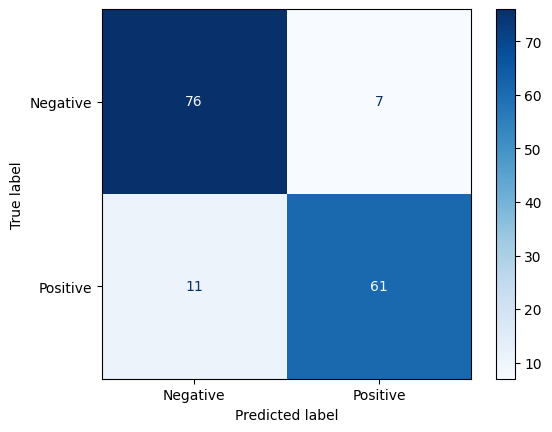

In [19]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelLSTM.eval()  # Set the model to evaluation mode

# Initialize variables to keep track of correct predictions and true labels
correct = 0
total = 0
all_preds = []
all_targets = []
batch_size  =32
# No need to calculate gradients during testing
with torch.no_grad():
    for i in range(0, X_test.size(0), batch_size):
        # Get the current test batch
        batch_data = X_test[i:i + batch_size]
        batch_targets = y_test_binary[i:i + batch_size]

        # Reshape the batch targets to match the shape of outputs
        batch_targets = batch_targets.unsqueeze(1)  # Make it (batch_size, 1)

        # Forward pass to get predictions
        outputs,_,_= modelLSTM(batch_data)


        # Apply sigmoid to get probabilities, and convert to binary predictions (0 or 1)
        
        predicted = (outputs > 0.5).float()  # Threshold at 0.41 for binary classification
        

        # Store predictions and true labels for confusion matrix
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_targets.cpu().numpy())

        # Update the count of correct predictions
        total += batch_targets.size(0)  # Total number of samples in this batch
        correct += (predicted == batch_targets).sum().item()  # Count correct predictions

# Calculate accuracy
accuracy = correct / total * 100  # Convert to percentage
print(f'Accuracy on the test set: {accuracy:.2f}%')

# Generate confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])  # Modify as per your labels
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [5]:
os.chdir(r"C:\Users\timur\Documents\GitHub\EmailSentin\backend_docker\mlflow")
!mlflow server --port 5000

^C
